In [1]:
!pip install easyfsl
!pip install scikit-learn
!pip install efficientnet_pytorch

Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable


In [2]:
import torch
from torch import nn, optim
from torch.utils.data import DataLoader
import numpy as np

from torchvision import transforms
from efficientnet_pytorch import EfficientNet
from torchvision.datasets import VisionDataset
from torchvision.datasets.utils import list_dir, list_files

from tqdm import tqdm
from PIL import Image
from os.path import join
from typing import Any, Callable, List, Optional, Tuple

from easyfsl.samplers import TaskSampler
from easyfsl.utils import plot_images, sliding_average

from sklearn.metrics import auc, roc_curve, confusion_matrix, classification_report

# **<span style="color:#0DA7FF">Important Variables</span>**

In [3]:
colorMode = "RGB"  # Color = 'RGB' || Grayscale = 'L'
image_size = 64  # Image size in pixels

N_WAY = 5  # Number of classes in a task
N_SHOT = 5  # Number of images per class in the support set
N_QUERY = N_SHOT  # Number of images per class in the query set

N_TRAINING_EPISODES = 5000     # Number of tasks to sample during training
N_EVALUATION_TASKS = 1000       # Number of tasks to sample for meta-evaluation

Dataset_Root_Folder = "../data"
Dataset_Name = "PlantVillage-Trim-100"

### <span style="color:#32FF0D">Custom Dataset Class</span>

In [4]:
class Dataset(VisionDataset):

    folder = Dataset_Name

    def __init__(
        self,
        root: str,
        background: bool = True,
        transform: Optional[Callable] = None,
        target_transform: Optional[Callable] = None,
    ) -> None:
        super().__init__(join(root, self.folder), transform=transform, target_transform=target_transform)
        self.background = background

        self.target_folder = join(self.root, self._get_target_folder())
        self._plant = list_dir(self.target_folder)
        self._leafs: List[str] = sum(
            ([join(a, c) for c in list_dir(join(self.target_folder, a))] for a in self._plant), []
        )
        self._leaf_images = [
            [(image, idx) for image in list_files(join(self.target_folder, leaf), ".JPG")]
            for idx, leaf in enumerate(self._leafs)
        ]
        self._flat_leaf_images: List[Tuple[str, int]] = sum(self._leaf_images, [])

    def __len__(self) -> int:
        return len(self._flat_leaf_images)

    def __getitem__(self, index: int) -> Tuple[Any, Any]:
        image_name, plant_leaf_class = self._flat_leaf_images[index]
        image_path = join(self.target_folder, self._leafs[plant_leaf_class], image_name)
        image = Image.open(image_path, mode="r").convert(colorMode)

        if self.transform:
            image = self.transform(image)

        if self.target_transform:
            plant_leaf_class = self.target_transform(plant_leaf_class)

        return image, plant_leaf_class

    def _get_target_folder(self) -> str:
        return "images_background" if self.background else "images_evaluation"

In [5]:
train_set = Dataset(
    root=Dataset_Root_Folder,
    background=True,
    transform=transforms.Compose(
        [
            transforms.RandomResizedCrop(image_size),
            transforms.RandomHorizontalFlip(),
            transforms.ToTensor(),
        ]
    ),
)
test_set = Dataset(
    root=Dataset_Root_Folder,
    background=False,
    transform=transforms.Compose(
        [
            transforms.Resize([int(image_size * 1.15), int(image_size * 1.15)]),
            transforms.ToTensor(),
        ]
    ),
)

### <span style="color:#00F7FF">Prototypical Network Class with EfficientNet CNN</span>

In [6]:
class PrototypicalNetworks(nn.Module):
    def __init__(self, backbone: nn.Module):
        super(PrototypicalNetworks, self).__init__()
        self.backbone = backbone

    def forward(
        self,
        support_images: torch.Tensor,
        support_labels: torch.Tensor,
        query_images: torch.Tensor,
    ) -> torch.Tensor:

        z_support = self.backbone.forward(support_images)
        z_query = self.backbone.forward(query_images)

        n_way = len(torch.unique(support_labels))
        z_proto = torch.cat(
            [
                z_support[torch.nonzero(support_labels == label)].mean(0)
                for label in range(n_way)
            ]
        )
        
        dists = torch.cdist(z_query, z_proto)
        scores = -dists
        return scores

efficientnet_model = EfficientNet.from_pretrained('efficientnet-b0')
efficientnet_model._fc = nn.Flatten()

model = PrototypicalNetworks(efficientnet_model).cuda()

Loaded pretrained weights for efficientnet-b0


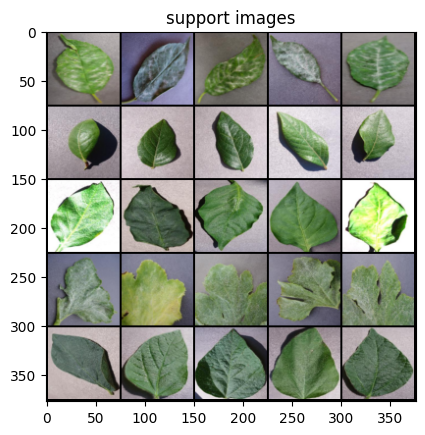

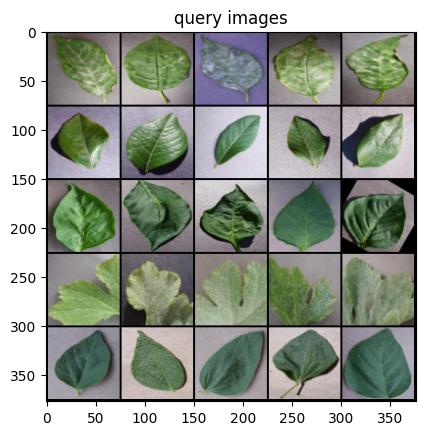

In [7]:
test_set.get_labels = lambda: [instance[1] for instance in test_set._flat_leaf_images]
test_sampler = TaskSampler(
    test_set, n_way=N_WAY, n_shot=N_SHOT, n_query=N_QUERY, n_tasks=N_EVALUATION_TASKS
)

test_loader = DataLoader(
    test_set,
    batch_sampler=test_sampler,
    num_workers=12,
    pin_memory=True,
    collate_fn=test_sampler.episodic_collate_fn,
)

(
    example_support_images,
    example_support_labels,
    example_query_images,
    example_query_labels,
    example_class_ids,
) = next(iter(test_loader))

plot_images(example_support_images, "support images", images_per_row=N_SHOT)
plot_images(example_query_images, "query images", images_per_row=N_QUERY)

In [8]:
def evaluate_on_one_task(
    support_images: torch.Tensor,
    support_labels: torch.Tensor,
    query_images: torch.Tensor,
    query_labels: torch.Tensor,
) -> [int, int]:
    """
    Returns the number of correct predictions of query labels, and the total number of predictions.
    """
    return (
        torch.max(
            model(support_images.cuda(), support_labels.cuda(), query_images.cuda())
            .detach()
            .data,
            1,
        )[1]
        == query_labels.cuda()
    ).sum().item(), len(query_labels)
    
def evaluate(data_loader: DataLoader):
    total_predictions = 0
    correct_predictions = 0

    model.eval()
    with torch.no_grad():
        for episode_index, (
            support_images,
            support_labels,
            query_images,
            query_labels,
            class_ids,
        ) in tqdm(enumerate(data_loader), total=len(data_loader)):

            correct, total = evaluate_on_one_task(
                support_images, support_labels, query_images, query_labels
            )

            total_predictions += total
            correct_predictions += correct

    print(
        f"Model tested on {len(data_loader)} tasks. Accuracy: {(100 * correct_predictions/total_predictions):.2f}%"
    )

In [9]:
train_set.get_labels = lambda: [instance[1] for instance in train_set._flat_leaf_images]
train_sampler = TaskSampler(
    train_set, n_way=N_WAY, n_shot=N_SHOT, n_query=N_QUERY, n_tasks=N_TRAINING_EPISODES
)
train_loader = DataLoader(
    train_set,
    batch_sampler=train_sampler,
    num_workers=12,
    pin_memory=True,
    collate_fn=train_sampler.episodic_collate_fn,
)

In [10]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

def fit(
    support_images: torch.Tensor,
    support_labels: torch.Tensor,
    query_images: torch.Tensor,
    query_labels: torch.Tensor,
) -> float:
    optimizer.zero_grad()
    classification_scores = model(
        support_images.cuda(), support_labels.cuda(), query_images.cuda()
    )

    loss = criterion(classification_scores, query_labels.cuda())
    loss.backward()
    optimizer.step()

    return loss.item()

### <span style="color:#00F7FF">Train Few Shot Model</span>

In [11]:
log_update_frequency = 10

all_loss = []
model.train()
with tqdm(enumerate(train_loader), total=len(train_loader)) as tqdm_train:
    for episode_index, (
        support_images,
        support_labels,
        query_images,
        query_labels,
        _,
    ) in tqdm_train:
        loss_value = fit(support_images, support_labels, query_images, query_labels)
        all_loss.append(loss_value)

        if episode_index % log_update_frequency == 0:
            tqdm_train.set_postfix(loss=sliding_average(all_loss, log_update_frequency))

100%|██████████| 5000/5000 [05:57<00:00, 13.99it/s, loss=0.0871]


### Save Trained Model

In [12]:
import time
PATH = "../model-saves/EfficientNet/"+str(N_WAY)+"-way "+str(N_SHOT)+"-shot plant leaf classification Trim "+time.strftime("%Y-%m-%d-%H%M%S")
torch.save(model, PATH)

### Load Model

In [13]:
# model = torch.load("../model-saves/EfficientNet/5-way 5-shot plant leaf classification2023-11-14-184846")

### Calculate Accuracy (in %)

In [14]:
evaluate(test_loader)

100%|██████████| 1000/1000 [00:28<00:00, 35.21it/s]

Model tested on 1000 tasks. Accuracy: 81.32%


### Calculate Top-K Accuracy (in %)

In [15]:
def top_k_accuracy(query_labels, predicted_scores, k=1):
    num_classes = predicted_scores.size(1)  # Get the number of classes

    if k > num_classes:
        k = num_classes  # Set k to the number of classes if it exceeds

    # Sort predicted scores in descending order and get the indices of the top-k predictions
    _, topk_indices = torch.topk(predicted_scores, k, dim=1, largest=True, sorted=True)
    
    correct_predictions = 0
    total_predictions = query_labels.size(0)
    
    for i in range(total_predictions):
        if query_labels[i] in topk_indices[i]:
            correct_predictions += 1

    accuracy = correct_predictions / total_predictions
    return accuracy

def evaluate_with_topk(data_loader, topk=1):
    total_predictions = 0
    correct_predictions = 0

    model.eval()
    with torch.no_grad():
        for episode_index, (
            support_images,
            support_labels,
            query_images,
            query_labels,
            class_ids,
        ) in tqdm(enumerate(data_loader), total=len(data_loader)):

            classification_scores = model(
                support_images.cuda(), support_labels.cuda(), query_images.cuda()
            )

            _, predicted_labels = torch.max(classification_scores.data, 1)

            correct, total = evaluate_on_one_task(
                support_images, support_labels, query_images, query_labels
            )

            total_predictions += total
            correct_predictions += correct

    accuracy = correct_predictions / total_predictions
    topk_accuracy = top_k_accuracy(query_labels, classification_scores, topk)

    # Calculate top-3 accuracy
    top3_accuracy = top_k_accuracy(query_labels, classification_scores, 3)
    
    return accuracy, topk_accuracy, top3_accuracy

# Evaluate the model with top-1, top-3, and top-5 accuracy
accuracy, top5_accuracy, top3_accuracy = evaluate_with_topk(test_loader, topk=5)
print(f"Top-1 Accuracy: {accuracy * 100:.2f}%")
print(f"Top-3 Accuracy: {top3_accuracy * 100:.2f}%")
print(f"Top-5 Accuracy: {top5_accuracy * 100:.2f}%")

100%|██████████| 1000/1000 [00:51<00:00, 19.32it/s]

Top-1 Accuracy: 81.11%
Top-3 Accuracy: 96.00%
Top-5 Accuracy: 100.00%


### Model Confusion Matrix & Classification Report

In [16]:
def create_confusion_matrix(data_loader):
    true_labels = []
    predicted_labels = []

    model.eval()
    with torch.no_grad():
        for episode_index, (
            support_images,
            support_labels,
            query_images,
            query_labels,
            _,
        ) in tqdm(enumerate(data_loader), total=len(data_loader)):

            classification_scores = model(
                support_images.cuda(), support_labels.cuda(), query_images.cuda()
            )

            _, predicted = torch.max(classification_scores.data, 1)

            true_labels.extend(query_labels.cpu().numpy())
            predicted_labels.extend(predicted.cpu().numpy())

    cm = confusion_matrix(true_labels, predicted_labels)
    report = classification_report(true_labels, predicted_labels)

    return cm, report

confusion_matrix_result, classification_report_result = create_confusion_matrix(test_loader)
print("Confusion Matrix:")
print(confusion_matrix_result)

print("Classification Report:")
print(classification_report_result)


100%|██████████| 1000/1000 [00:28<00:00, 35.01it/s]

Confusion Matrix:
[[4406   98  186  175  135]
 [ 160 4154  242  255  189]
 [ 142  292 4036  293  237]
 [ 223  317  337 3904  219]
 [ 172  283  366  461 3718]]
Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.88      0.87      5000
           1       0.81      0.83      0.82      5000
           2       0.78      0.81      0.79      5000
           3       0.77      0.78      0.77      5000
           4       0.83      0.74      0.78      5000

    accuracy                           0.81     25000
   macro avg       0.81      0.81      0.81     25000
weighted avg       0.81      0.81      0.81     25000



### Calculate Model AUC

In [17]:
def create_confusion_matrix(data_loader, model):
    true_labels = []
    predicted_probs = []

    model.eval()
    with torch.no_grad():
        for episode_index, (
            support_images,
            support_labels,
            query_images,
            query_labels,
            _,
        ) in tqdm(enumerate(data_loader), total=len(data_loader)):

            classification_scores = model(
                support_images.cuda(), support_labels.cuda(), query_images.cuda()
            )

            # Extract probability scores
            probabilities = torch.nn.functional.softmax(classification_scores, dim=1)
            predicted_probs.extend(probabilities.cpu().numpy())

            true_labels.extend(query_labels.cpu().numpy())

    # Convert true labels to one-hot encoding
    true_labels_one_hot = np.eye(len(np.unique(true_labels)))[true_labels]

    # Calculate micro-average ROC AUC
    fpr, tpr, _ = roc_curve(true_labels_one_hot.ravel(), np.array(predicted_probs).ravel())
    roc_auc = auc(fpr, tpr)

    return roc_auc

auc_result = create_confusion_matrix(test_loader, model)
print("Micro-average AUC-ROC:", auc_result)

100%|██████████| 1000/1000 [00:27<00:00, 36.65it/s]

Micro-average AUC-ROC: 0.9638875862
